In [133]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import os,sys
import warnings
from xrsana import math_functions
from scipy.optimize import curve_fit

In [134]:
PROJECT_ROOT = "/home/hushiqi/work/xrs_ana"
SCAN_NAME = "Ho_Comptonscan"
DATA_PATH = os.path.join(PROJECT_ROOT, "ex_space", "analysis", "data", SCAN_NAME)
RESULT_PATH = os.path.join(PROJECT_ROOT, "ex_space", "analysis", "result")
RESULT_DIR = os.path.join(RESULT_PATH, SCAN_NAME)
SQW_PATH = os.path.join(RESULT_DIR, "result.dat")
os.makedirs(RESULT_DIR, exist_ok=True)
os.environ.setdefault("MPLCONFIGDIR", "/tmp/matplotlib-xrsana")
warnings.filterwarnings("ignore", category=RuntimeWarning)

sys.path.insert(0, PROJECT_ROOT)

from xrsana import xrs_extraction, xrs_read

Loading HEPS ID33 reduced data : /home/hushiqi/work/xrs_ana/ex_space/analysis/data/Ho_Comptonscan

Reader summary
scan_name       : Ho_Comptonscan
E0 (keV)        : 9.683032643850813
q average       : 9.58704206984813
tth (deg)       : [155.2971955488892]
eloss shape     : (4001,)
signals shape   : (4001, 1)
errors shape    : (4001, 1)
selected ROIs   : 12
analyzer key    : {'Analyzer01': 0}
average signal  : (4001,)
average error   : (4001,)
average q head  : [5.07352433 5.07352433 5.07352433 5.07352433 5.07352433]


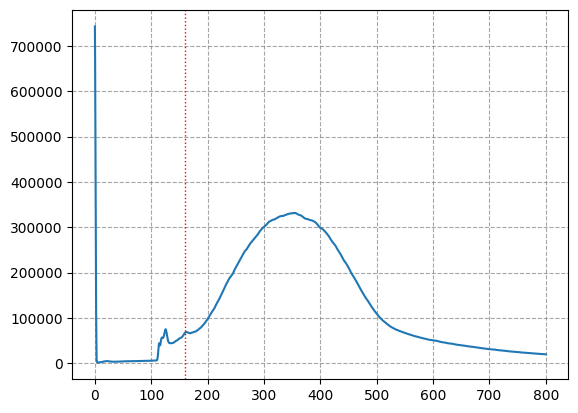

In [135]:
print("Loading HEPS ID33 reduced data :", DATA_PATH)
data = xrs_read.read_heps_id33(DATA_PATH)

print("\nReader summary")
print("scan_name       :", data.scan_name)
print("E0 (keV)        :", data.E0)
print("q average       :", data.q_average)
print("tth (deg)       :", data.tth)
print("eloss shape     :", data.eloss.shape)
print("signals shape   :", data.signals.shape)
print("errors shape    :", data.errors.shape)
print("selected ROIs   :", len(data.selected_rois))
print("analyzer key    :", data.key)
data_ex = xrs_extraction.edge_extraction(data, ["Ho"], [1.0], {"Ho": ["N5"]})
data_ex.analyzerAverage([0], errorweighing=True)
print("average signal  :", data_ex.avsignals.shape)
print("average error   :", data_ex.averrors.shape)
print("average q head  :", data_ex.avqvals[:5])

plt.plot(data.eloss, data.signals)
plt.grid(True, linestyle='--', alpha=0.7, color='gray')
plt.axvline(x=160, color='red', linestyle=':', linewidth=1)
plt.show()

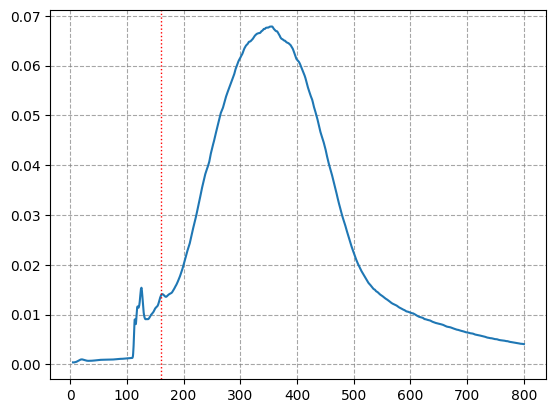

In [136]:
data_ex = xrs_extraction.edge_extraction(data,['Ho'],[1.0],{'Ho':['N4','N5']})
data_ex_cut = data_ex.truncate(5,800, copy_obj=True)
plt.plot(data_ex_cut.eloss, data_ex_cut.signals)
plt.grid(True, linestyle='--', alpha=0.7, color='gray')
plt.axvline(x=160, color='red', linestyle=':', linewidth=1)
plt.show()

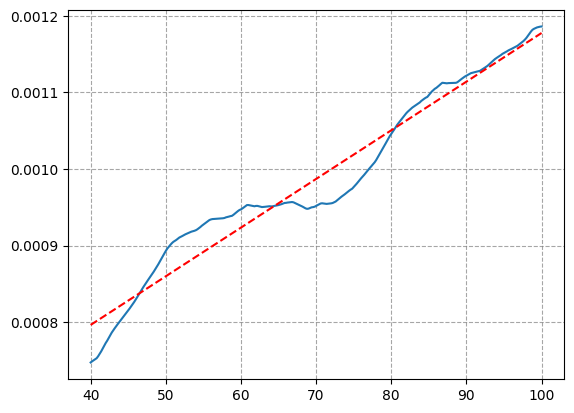

In [137]:
min_eloss = 40
max_eloss = 100
mask = (data_ex_cut.eloss >= min_eloss) & (data_ex_cut.eloss <= max_eloss)

k, b = np.polyfit(data_ex_cut.eloss[mask], data_ex_cut.signals[mask, 0], deg=1)
#first step remove
stray_background = k * data_ex_cut.eloss[mask] + b
plt.plot(data_ex_cut.eloss[mask], data_ex_cut.signals[mask, 0])  
plt.plot(data_ex_cut.eloss[mask], stray_background, color='red', linestyle='--')
plt.grid(True, linestyle='--', alpha=0.7, color='gray')
plt.show()

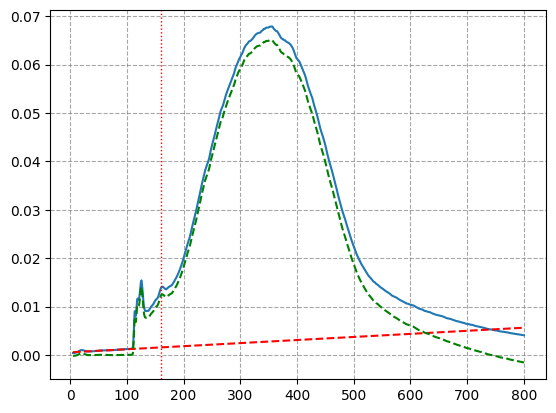

In [138]:
plt.plot(data_ex_cut.eloss, data_ex_cut.signals)
stray_background = k * data_ex_cut.eloss + b
plt.plot(data_ex_cut.eloss, stray_background, color='red', linestyle='--')
plt.grid(True, linestyle='--', alpha=0.7, color='gray')
plt.axvline(x=160, color='red', linestyle=':', linewidth=1)
data_ex_removestray = data_ex_cut.signals[:, 0] - (k * data_ex_cut.eloss + b)
plt.plot(data_ex_cut.eloss, data_ex_removestray, color='green', linestyle='--')
data_ex_cut.signals[:, 0] = data_ex_removestray
plt.show()


In [139]:
#Sample self-absorption and absorption of the incident X-ray beam between the incident flux monitor and the sample were corrected for.


The fit parameters are:  [ 9.87271376e-01 -1.18243372e-07 -1.00282097e-04  7.07714265e-03]


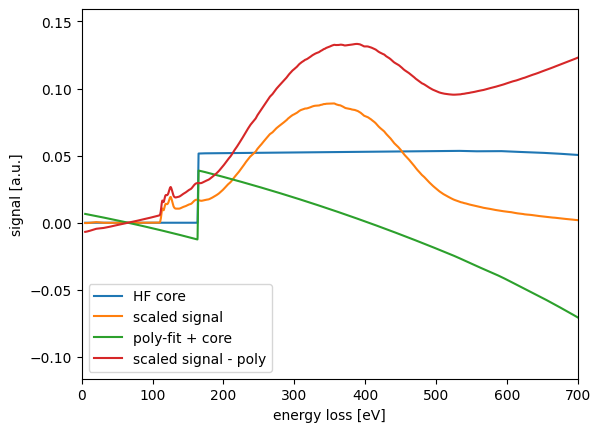

In [158]:
data_ex_cut.analyzerAverage([0],errorweighing=False)
data_ex_cut.removePolyCoreAv('Ho','N4',[100,150],[200,600],weights=[2,1],guess=[1.0,0.0,0.0,0.0,],ewindow=100)

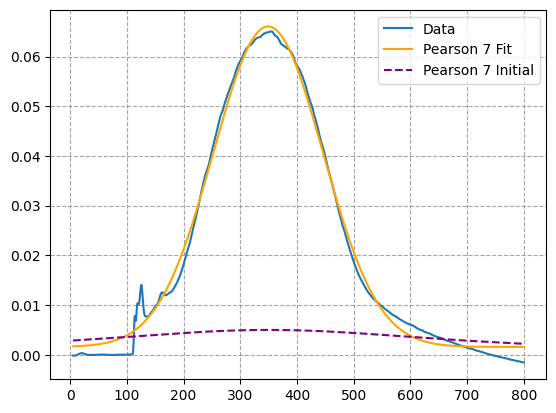

In [141]:
p0 = [350,800,1, 0.005, 0]
min_eloss = 110
max_eloss = 800
mask = (data_ex_cut.eloss >= min_eloss) & (data_ex_cut.eloss <= max_eloss)

popt, pcov = curve_fit(
    math_functions.pearson7_forcurvefit,
    data_ex_cut.eloss[mask],
    data_ex_cut.signals[mask, 0],
    p0=p0
)
pearson_peak_manual = math_functions.pearson7(data_ex_cut.eloss, p0)
pearson_peak = math_functions.pearson7(data_ex_cut.eloss, popt)
plt.plot(data_ex_cut.eloss, data_ex_cut.signals[:, 0], label='Data')
plt.plot(data_ex_cut.eloss, pearson_peak, label='Pearson 7 Fit', color='orange')
plt.plot(data_ex_cut.eloss, pearson_peak_manual, label='Pearson 7 Initial', color='purple', linestyle='--')
plt.grid(True, linestyle='--', alpha=0.7, color='gray')
#plt.axvline(x=160, color='red', linestyle=':', linewidth=1)
plt.legend()
plt.show()  